<a href="https://colab.research.google.com/github/aidenjbrown/Intermediate_Data_Science_CS_28/blob/main/scripts/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. What is your outcome variable(s)? How well does it measure the outcome you are interested? How does it relate to your expectations?

Our outcome variable is depression score. It measures the outcome we are interested in very well because it is the exact criteria the CDC uses to estimate the prevalence of depression across the population.

## 2. What are your key explanatory variables?

Our key explanatory variables are race (RIDRETH3 and race_label), income (INDHHIN2 / income_label), hours worked last week (OCQ180), and level of education (DMDEDUC2 / education_label). We also include sleep-related variables such as weekday sleep hours (SLD012), weekend sleep hours (SLD013), perception of weight (WHQ030), and BMI (computed from WHD010 and WHD020).

## 3. What data cleaning did you have to do?

We had to clean the data by replacing any depression symptom indicator that was not between 0 and 3 with a NaN so the scores could only reach a max of 27 (which is the max score for depression screening in the NHANES). We also cleaned explanatory variables by converting them to numeric and replacing NHANES special codes such as 77777 and 99999 in OCQ180, and 77 and 99 in sleep variables like SLD012 and SLD013 with NaN.

## 4. How did you wrangle the data?

We wrangled the data by performing an inner merge on all of the 4 raw datasets by SEQN number. We chose an inner merge because we wanted to have the most data per row possible even if it meant dropping some participants. We also dropped all of the variables we did not need from the raw data by choosing to only keep the subset that we did need, including OCQ180, SLD012, SLD013, WHQ030, WHD010, WHD020, and depression_score.

## 5. Are you deciding to exclude any observations? If so, why?

We are deciding to exclude any observations that have NaN for depression_score since it is our key outcome variable and if a participant does not have that score calculated, that participant is not useful for this data analysis. We also excluded any participants that did not answer at least 6 out of the 9 depression indicator questions because we wanted to minimize skewing the data to the left due to participants simply answering fewer questions. In addition, we excluded invalid or missing values in explanatory variables such as OCQ180, SLD012, SLD013, WHD010, and WHD020.

## 6. Did you have to create any new variables from existing variables? If so, how and why?

We did have to create the depression score variable (depression_score) because it was not calculated for us. So if the answer to each question related to depression symptoms had between a 0 and 3 as a response, we added it to the other responses for the same participant for all the depression symptoms to get a score with the max being 27. We wanted to create this variable so we could determine if certain predictors were associated with depression more broadly rather than individual symptoms only. Additionally, we created new variables for any of the encoded categorical variables such as income or race because the encoded values were hard to interpret without looking at the dataset's codebook. We also created BMI using WHD010 and WHD020 using the formula 703 * (WHD020 / WHD010^2).

In [138]:
# Supressing warnings and messages.
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Importing the data

from google.colab import drive
drive.mount('/content/drive')

depression = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/DPQ_J.xpt')
depression.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Depression_Scores.csv', index=False)

income = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/INQ_J.xpt')
income.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Income.csv', index=False)

demographics = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/DEMO_J.xpt')
demographics.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Demographics.csv', index=False)

sleep = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/SLQ_J.xpt')
sleep.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Sleep.csv', index=False)

occupation = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/OCQ_J.xpt')
occupation.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Occupation.csv', index=False)

weight = pd.read_sas('/content/drive/MyDrive/DataScienceXPTFiles/WHQ_J.xpt')
weight.to_csv('/content/drive/MyDrive/DataScienceXPTFiles/Weight.csv', index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [139]:
# Now we will merge all of the data based on the SEQN number. We are using inner merge to make sure the SEQN exists in both datasets.

merge1 = pd.merge(depression, income, on='SEQN', how = "inner")
print(merge1.shape)
merge2 = pd.merge(merge1, demographics, on='SEQN', how = "inner")
print(merge2.shape)
merge3 = pd.merge(merge2, occupation, on='SEQN', how = "inner")
print(merge3.shape)
df = pd.merge(merge3, sleep, on='SEQN', how = "inner").merge(weight, on='SEQN', how = "inner")
print(df.shape)

# Now we want to determine what explanatory variables we are going to keep.

(5533, 26)
(5533, 71)
(5533, 80)
(5533, 126)


In [140]:

import numpy as np

# First we are going to replace any response with NaN for the depression indicators that aren't a valid depression score (0-3,) in other words, the responses that did not mention whether
# or how often they were feeling this way. We are ignoring the variable (DPQ100) that asks about the difficulty the problems have causec because it is
# not directly related to depression score and uses a different encoding system.

depression_cols = ["DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050", "DPQ060", "DPQ070", "DPQ080", "DPQ090"]


# Using a Lamda expression here so we can get the data we want (between 0 and 3) for each collumn at a time.
df[depression_cols] = df[depression_cols].apply(lambda x: x.where(x.between(0, 3)))

# Before calculating the depression score, we need to reformat the data so that it is no longer in scientific notation (a quirk of the original .xpt file)

# Operating only on the depression and IMDFMPIR columns.
df[depression_cols] = df[depression_cols].mask(df[depression_cols].abs() < 1e-10)
df["INDFMPIR"] = df["INDFMPIR"].mask(df["INDFMPIR"].abs() < 1e-10)



# Now we want to drop all of the observations of participants who did not answer at least seven of the questions related to depression screening. We first do this by counting how many
# missing responses we have for each participant then using a similar masking strategy. Originally we wanted the participant to answer all the questons, but this got rid of too mnay observations.

count = df[depression_cols].notna().sum(axis=1)
count_mask = count >= 6
df = df[count_mask].copy()

# Creating an aggregated depression score out of 27 estimating the severity of the participant's depression.

df["depression_score"] = df[depression_cols].sum(axis=1)
print(df.shape)

(568, 127)


In [141]:


# Some of the data is in byte format so, I use the decode comment if it is
df = df.map(lambda x: x.decode() if isinstance(x, bytes) else x)

# Remove NaN variables.

df["OCQ180"] = pd.to_numeric(df["OCQ180"], errors="coerce").replace([77777, 99999], np.nan)
df["SLD012"] = pd.to_numeric(df["SLD012"], errors="coerce").replace([77, 99], np.nan)
df["SLD013"] = pd.to_numeric(df["SLD013"], errors="coerce").replace([77, 99], np.nan)
df["WHD010"] = pd.to_numeric(df["WHD010"], errors="coerce").replace([7777, 9999], np.nan)
df["WHD020"] = pd.to_numeric(df["WHD020"], errors="coerce").replace([7777, 9999], np.nan)

In [142]:
# Now it is time to drop all of the variables we don't need

columns_we_want = ["SEQN","WHD010","WHD020", "WHQ030", "SLD012", "SLD013", "RIAGENDR", "RIDRETH3", "INDHHIN2", "INDFMPIR", "DMDEDUC2", "DMDEDUC3", "OCQ180", "depression_score"]
df = df[columns_we_want].copy()
# Sumarizing the numerical columns.
df[["depression_score", "WHD010","WHD020", "SLD012", "SLD013", "INDFMPIR", "OCQ180"]].describe().round(2)


,depression_score,WHD010,WHD020,SLD012,SLD013,INDFMPIR,OCQ180
count,568.00,553.00,552.00,559.00,560.00,487.00,207.00
mean,12.17,66.02,188.03,7.63,8.21,2.04,37.57
std,4.46,4.18,52.15,1.93,2.03,1.45,13.98
min,6.00,51.00,89.00,2.00,2.00,0.04,5.00
25%,9.00,63.00,154.00,6.50,7.00,0.90,29.00
50%,11.00,66.00,180.00,7.50,8.00,1.64,40.00
75%,15.00,69.00,217.00,9.00,9.50,2.81,45.00
max,25.00,78.00,457.00,14.00,13.00,5.00,80.00


In [155]:
import seaborn as sns
import matplotlib.pyplot as plt


# First we want to work on comparing race vs depression score, so we map the actual categorical variables onto the encoded variables for race.

race_map = {1: "Mexican American",
            2: "Other Hispanic",
            3: "Non-Hispanic White",
            4: "Non-Hispanic Black",
            6: "Non-Hispanic Asian",
            7: "Other Race"
            }
df["race_label"]= df["RIDRETH3"].map(race_map)

# Summary table of race

frequency = df["race_label"].value_counts()
percent = df["race_label"].value_counts(normalize=True) * 100

pd.DataFrame({
    "Count": frequency,
    "Percent": percent.round(2)
})

,Count,Percent
race_label,,
Non-Hispanic White,233,41.02
Non-Hispanic Black,109,19.19
Mexican American,84,14.79
Other Hispanic,60,10.56
Other Race,47,8.27
Non-Hispanic Asian,35,6.16


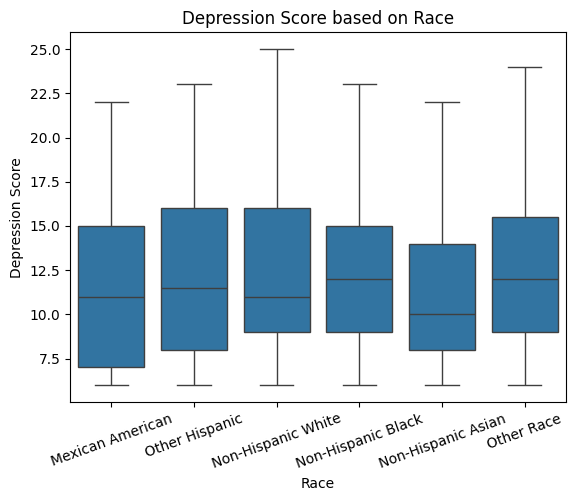

In [144]:
# Before we make the box plot, we have to put the race categories in the order the dataset did.


order = ["Mexican American",  "Other Hispanic", "Non-Hispanic White", "Non-Hispanic Black", "Non-Hispanic Asian", "Other Race"]

# Making a box plot comparing depression score based on race.

sns.boxplot(x="race_label", y="depression_score", data=df, order = order)

plt.xlabel("Race")
plt.ylabel("Depression Score")
plt.title("Depression Score based on Race")

plt.xticks(rotation=20)

plt.show()



It appears that while most races have a median depression score of approximately 11, Asians have a median depression score of about 10, a whole point less than the average median score across races. Additionally Other Hispanics have a much wider distribution of depression scores between the first and third quartile compared to any of the other races. Otherwise, the distribution of depression scores is relatively uniform among all races, suggesting a weak relationship between race and depression score.

In [156]:
# Next we want to work on comparing education level of adults vs depression score, so now we map the actual categorical variables onto the encoded variables for education.

education_map = {
            1: "Less than 9th grade",
            2: "9-11th grade",
            3: "High school graduate/GED",
            4: "Some college or AA degree",
            5: "College graduate or above"
            }
df["education_label"]= df["DMDEDUC2"].map(education_map)


# Summary table of education levels.

frequency = df["education_label"].value_counts()
percent = df["education_label"].value_counts(normalize=True) * 100

pd.DataFrame({
    "Count": frequency,
    "Percent": percent.round(2)
})

,Count,Percent
education_label,,
Some college or AA degree,192,35.75
High school graduate/GED,157,29.24
College graduate or above,70,13.04
9-11th grade,61,11.36
Less than 9th grade,57,10.61


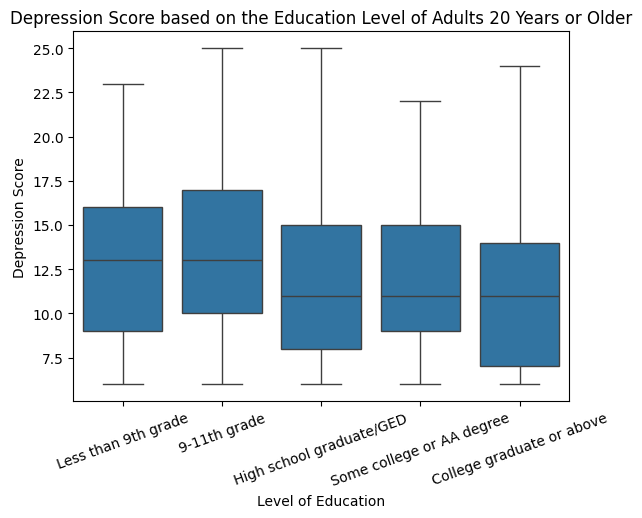

In [146]:
# Before we make the box plot, we put levels of education in order of least to most education.


order = ["Less than 9th grade",  "9-11th grade", "High school graduate/GED", "Some college or AA degree", "College graduate or above"]

# Making a box plot comparing depression score based to race.

sns.boxplot(x="education_label", y="depression_score", data=df, order = order)

plt.xlabel("Level of Education")
plt.ylabel("Depression Score")
plt.title("Depression Score based on the Education Level of Adults 20 Years or Older")


plt.xticks(rotation=20)

plt.show()

It appears that those who have graduated high school (or the equivalent) or have received a higher level of education have a substantially lower median depression score than those who did not reach this level of education. While the median depression score of those with less education than the equivalent of a high school degree is about 13, it is only about 10.5 for those who have received the equivalent of a high school education or higher.

In [158]:
# Now we want to work on comparing participants' income level to to their depression score, so lets map the actual categorical variables onto the encoded variables for income.

income_map = {
            1: "0-5k",
            2: "5k-10k",
            3: "10k-15k",
            4: "15k-20k",
            5: "20k-25k",
            6: "25k-35k",
            7: "35k-45k",
            8: "45k-55k",
            9: "55k-65k",
            10: "65k-75k",
            12: "20k and Over",
            13: "Under 20k",
            14: "75k-100k",
            15: "100k and Over"
            }
df["income_label"]= df["INDHHIN2"].map(income_map)


# Summary table of income levels:

frequency = df["income_label"].value_counts()
percent = df["income_label"].value_counts(normalize=True) * 100

pd.DataFrame({
    "Count": frequency,
    "Percent": percent.round(2)
})

,Count,Percent
income_label,,
25k-35k,71,13.87
35k-45k,62,12.11
100k and Over,54,10.55
20k-25k,49,9.57
15k-20k,43,8.40
10k-15k,41,8.01
75k-100k,40,7.81
45k-55k,39,7.62
5k-10k,27,5.27


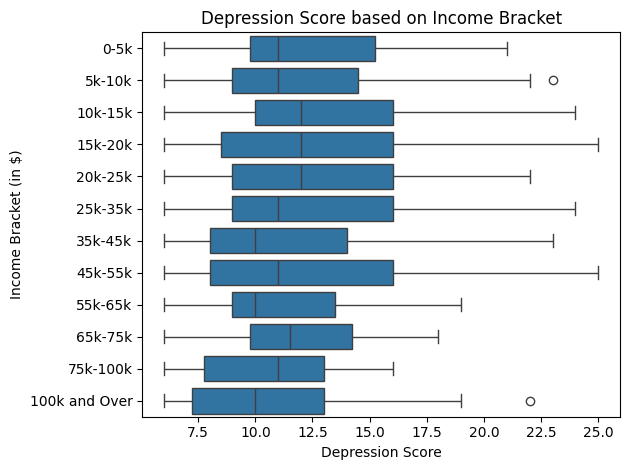

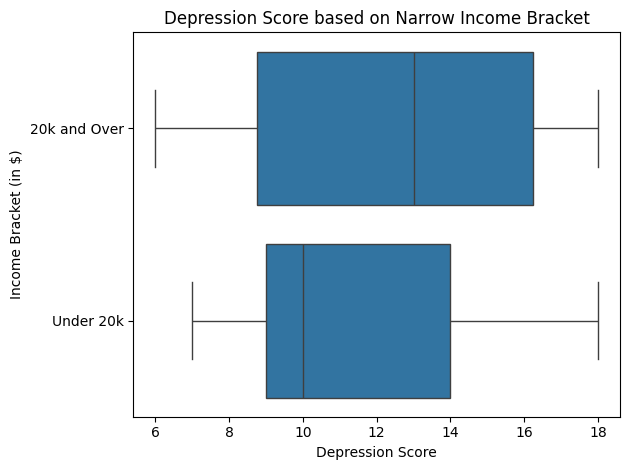

In [148]:
# Before we make the box plot, we have to put levels of income in the order the CDC put them in (more or less in the order of least to most income.)


order = [
          "0-5k",
          "5k-10k",
          "10k-15k",
          "15k-20k",
          "20k-25k",
          "25k-35k",
          "35k-45k",
          "45k-55k",
          "55k-65k",
          "65k-75k",
          "75k-100k",
          "100k and Over",
]

# Making a box plot comparing depression score based on race (but making it horizontal for readablility).

sns.boxplot(x="depression_score", y="income_label", data=df, order = order)

plt.ylabel("Income Bracket (in $)")
plt.xlabel("Depression Score")
plt.title("Depression Score based on Income Bracket")


plt.tight_layout()
plt.show()


new_order = [
    "20k and Over",
    "Under 20k"
]

# Making a similar box plot only comparing incomes less than $20k and greater than 20k.

sns.boxplot(x="depression_score", y="income_label", data=df, order = new_order)

plt.ylabel("Income Bracket (in $)")
plt.xlabel("Depression Score")
plt.title("Depression Score based on Narrow Income Bracket")


plt.tight_layout()
plt.show()

It appears that those whose households make 35,000 to 44,999, 55,000 to 64,999, 100,000 and over, and under 20,000 dollars have a substantially lower median depression score than those who make any other quantity of money. This is fascinating because the trend that a higher household income is correlated with a lower depression score is challenged by the fact that the median depression score for those whose household makes 20,000 dollars and over is much smaller than those who make under 20,000 dollars with the former and latter levels having median depression scores of approximately 10.5 and 13 respectively. Additionally, participants whose household income range from 0 to 54,999 dollars have a much higher spread of depression scores than those who make 55,000 dollars or more a year, suggesting that the range of depression scores decreases as income increases once the 55,000 dollar threshold is reached.

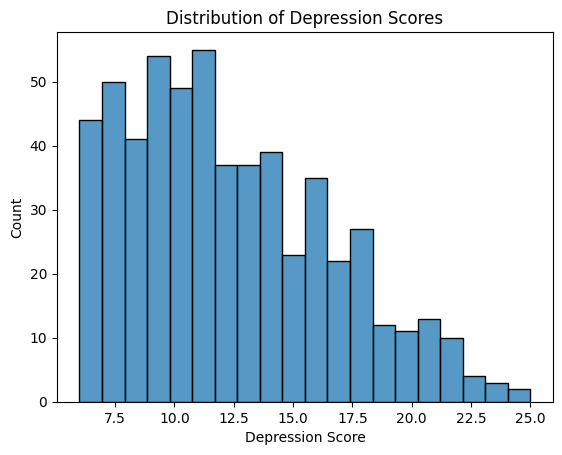

In [149]:
# Making a histogram of depression scores to determine which scores are most common across all participants

sns.histplot(data=df, x="depression_score", bins=20)

plt.xlabel("Depression Score")
plt.ylabel("Count")
plt.title("Distribution of Depression Scores")



plt.show()

Based on the histogram, the most common depression scores appear to be from about 10-12.5. Additionally, the histogram is skewed right which indicates that there is an observable minority of participants with a depression score greater than or equal to 12.5 (as there is no observed score above 25). Despite the skew, the majority of participants have a relatively low depression score.

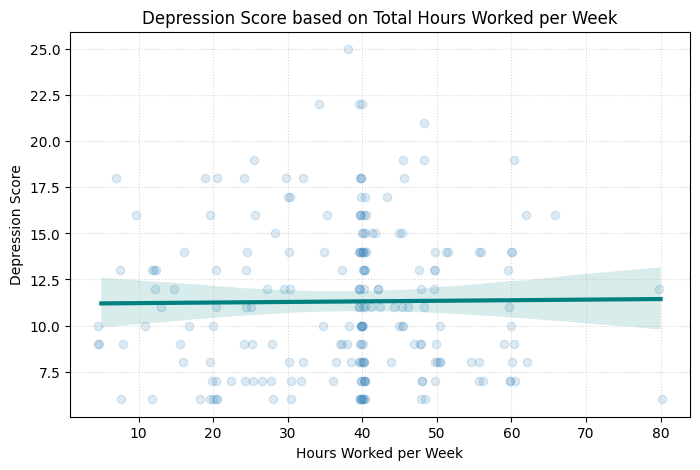

In [150]:
# select relevant columns and create a copy
tmp_work = df[['OCQ180', 'depression_score']].copy()

# convert to numeric and handle missing values or invalid codes
tmp_work['OCQ180'] = pd.to_numeric(tmp_work['OCQ180'], errors='coerce')

# replace nhanes codes for dont know and refused with null
tmp_work['OCQ180'] = tmp_work['OCQ180'].replace([77777, 99999], np.nan)

# remove rows with missing data
tmp_work = tmp_work.dropna(subset=['OCQ180', 'depression_score'])

# initialize the figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

# create a regression plot for work hours versus depression score
sns.regplot(
    data=tmp_work,
    x="OCQ180",
    y="depression_score",
    x_jitter=0.5,
    scatter_kws={'alpha': 0.15},
    line_kws={'color': 'teal', 'lw': 3},
    ax=ax
)

# set labels title and grid properties
plt.ylabel("Depression Score")
plt.xlabel("Hours Worked per Week")
plt.title("Depression Score based on Total Hours Worked per Week")
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

There is no clear relationship between depression scores based on hours worked per week, although there does seem to be a larger cluster of scores around 6.5 to 18.

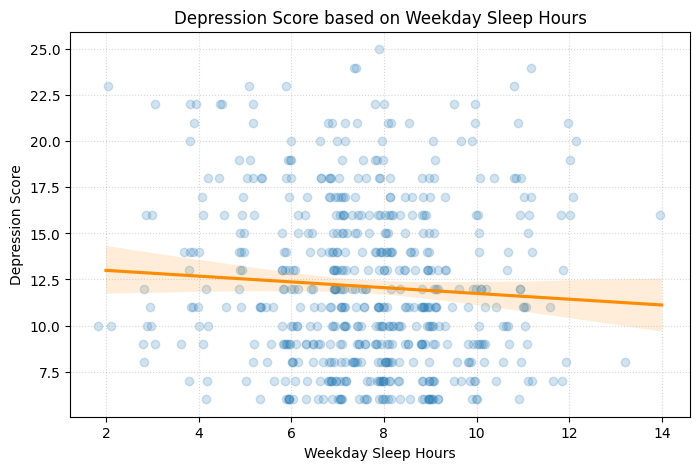

In [151]:
# prepare sleep data for analysis
tmp_sleep = df[['SLD012', 'depression_score']].copy()

# clean numeric data and handle missing sleep value codes
tmp_sleep['SLD012'] = pd.to_numeric(tmp_sleep['SLD012'], errors='coerce')
tmp_sleep['SLD012'] = tmp_sleep['SLD012'].replace([77, 99], np.nan)
tmp_sleep = tmp_sleep.dropna(subset=['SLD012', 'depression_score'])

# setup the plot area
fig, ax = plt.subplots(figsize=(8, 5))

# plot relationship between weekday sleep and depression
sns.regplot(
    data=tmp_sleep,
    x="SLD012",
    y="depression_score",
    x_jitter=0.2,
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkorange'},
    ax=ax
)

# add plot labels and styling
plt.ylabel("Depression Score")
plt.xlabel("Weekday Sleep Hours")
plt.title("Depression Score based on Weekday Sleep Hours")
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

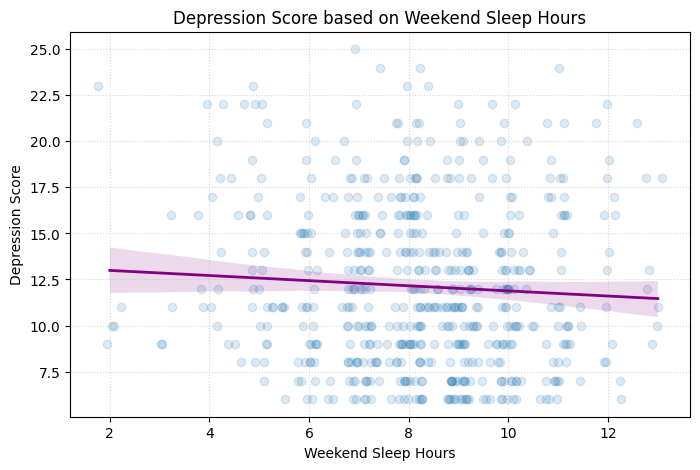

In [152]:
# extract weekend sleep data and score
tmp_weekend = df[['SLD013', 'depression_score']].copy()

# numeric conversion and removal of outlier codes
tmp_weekend['SLD013'] = pd.to_numeric(tmp_weekend['SLD013'], errors='coerce')
tmp_weekend['SLD013'] = tmp_weekend['SLD013'].replace([77, 99], np.nan)
tmp_weekend = tmp_weekend.dropna(subset=['SLD013', 'depression_score'])

# create plotting environment
fig, ax = plt.subplots(figsize=(8, 5))

# visualize weekend sleep correlation
sns.regplot(
    data=tmp_weekend,
    x="SLD013",
    y="depression_score",
    x_jitter=0.25,
    scatter_kws={'alpha': 0.15},
    line_kws={'color': 'purple', 'lw': 2},
    ax=ax
)

# finalize labels and show weekend plot
plt.ylabel("Depression Score")
plt.xlabel("Weekend Sleep Hours")
plt.title("Depression Score based on Weekend Sleep Hours")
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

There seem to be no clear trends between either weekend and weekday sleep hours and depression score. The only noticeable trend is weekend sleep hours are clustered more around 8.5 hours of sleep. For almost every sleep duration represented, there is significant vertical spread, suggesting that there are more factors at hand contributing to depression score.

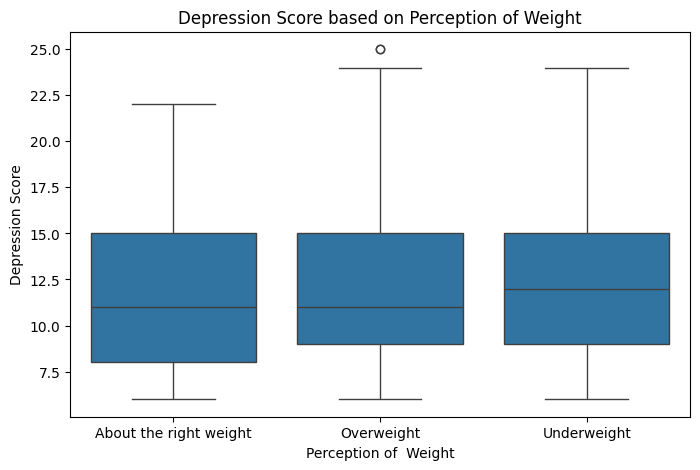

In [153]:
# isolate weight perception data
tmp2 = df[['WHQ030', 'depression_score']].copy()

# convert to numeric and nullify invalid response codes
tmp2['WHQ030'] = pd.to_numeric(tmp2['WHQ030'], errors='coerce')
tmp2['WHQ030'] = tmp2['WHQ030'].replace([7, 9], np.nan)

# drop missing values and map categorical labels to the codes
tmp2 = tmp2.dropna(subset=['WHQ030', 'depression_score'])
tmp2['WHQ030'] = tmp2['WHQ030'].map({
    1: "Overweight",
    2: "Underweight",
    3: "About the right weight",
})

# create boxplot for categorical weight perception
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=tmp2, y="depression_score", x="WHQ030", ax=ax)
plt.ylabel("Depression Score")
plt.xlabel("Perception of  Weight")
plt.title("Depression Score based on Perception of Weight")
plt.show()

It appears that the median depression score for the group that considers themselves underweight is slightly higher than both the other groups. Data from the overweight perception and underweight perception group have larger range than the "about the right weight" perception group.

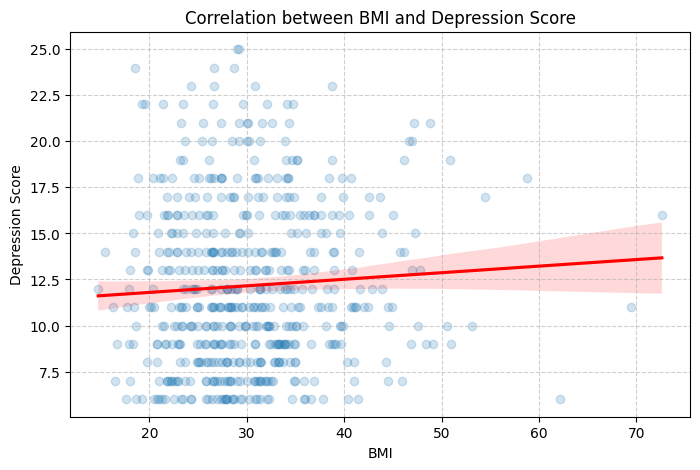

In [154]:
# gather height weight and depression columns
tmp3 = df[['WHD010', 'WHD020', 'depression_score']].copy()
tmp3['WHD010'] = pd.to_numeric(tmp3['WHD010'], errors='coerce')
tmp3['WHD020'] = pd.to_numeric(tmp3['WHD020'], errors='coerce')

# clean data by replacing missing indicators with null
tmp3['WHD010'] = tmp3['WHD010'].replace([7777, 9999,'.'], np.nan)
tmp3['WHD020'] = tmp3['WHD020'].replace([7777, 9999,'.'], np.nan)
tmp3 = tmp3.dropna(subset=['WHD010', 'WHD020', 'depression_score'])

# calculate bmi using height and weight formula
tmp3['bmi'] = 703 * (tmp3['WHD020'] / (tmp3['WHD010'] ** 2))

# generate regression plot for bmi versus depression
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(data=tmp3, x="bmi", y="depression_score",
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, ax=ax)

# apply visual labels and grid
plt.ylabel("Depression Score")
plt.xlabel("BMI")
plt.title("Correlation between BMI and Depression Score")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

There does not seem to be a clear trend between BMI and depression score. It does appear, however, that the data is centered around 30.